# Week 6: data visualization mastery with seaborn

***Seaborn** lib for statistical viualization*:
- built on matplotlib
- but designed specifically for statistical exploration
- it can handle heavy task like aggregating data and 
calculating confidnece intervals automatically

***Advanced** chart type*:
- box plot
- violon plot
- heatmaps

*Seaborn allow us to customize the charts with aesthetics and themes.*:

functions like set_style() & set_palette()

The best thing of seaborn lib is for its **subplots** feature.

**Plotly** allows us to make a interactive charts:
like **Hover, zoom or toggle**

## practicing the charts:

### Box plot

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#'Tipd' dataset included in seaborn
tips = sns.load_dataset("tips")
print(tips.head())
print(tips.shape)

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
(244, 7)


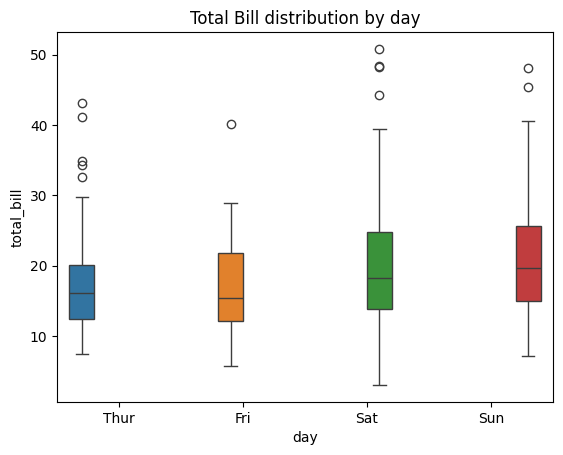

In [3]:
#ploting box plot:
sns.boxplot(data=tips, x='day', y='total_bill', hue='day', palette='tab10')
plt.title('Total Bill distribution by day')
plt.show()

Take away:
- **hue**: states to automaticallt grup the dataset and adds unique color
- **palette**: states the theme of the chart, and there is only 3 sets by default.
- update on palette; there are more then set1 2 and 3. like dark, rocket, mako, vlag, coolwarm, pastel

### HeatMaps

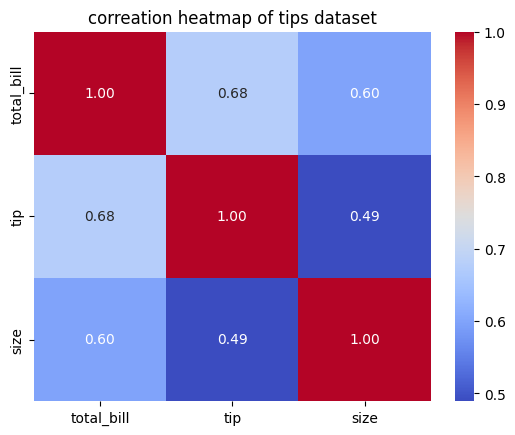

In [4]:
#calcutating correaltion(On only numerical columns)
corr = tips.select_dtypes('number').corr()

#heatmap creataion
sns.heatmap(corr, annot=True, cmap = 'coolwarm', fmt=".2f")

plt.title('correation heatmap of tips dataset')
plt.show()

take away:
- annot toggle the number shown inside the heatmap
- fmt (format string), used to lower the decimal number in the correlation we have here
- cmap is just used to color the heatmap

### Custom Styling the chart


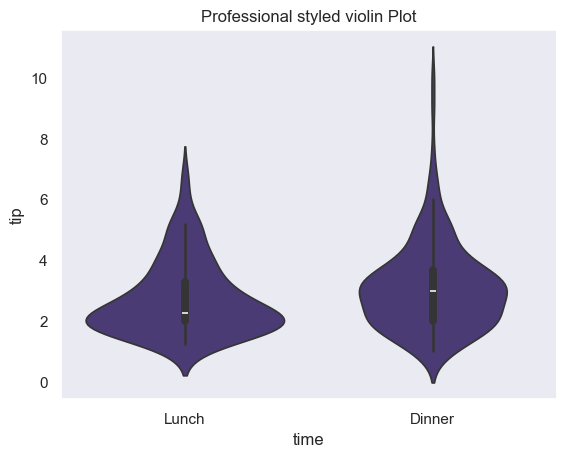

In [5]:
#applying a specific theme
sns.set_theme(style='dark',palette='viridis')

#plotting with new theme
sns.violinplot(data = tips, x='time', y='tip')

plt.title('Professional styled violin Plot')
plt.show()

take away:
- the style attribute in the set_them() is useless, i thought i the dark value give dark background but no it gave a blurly white
- violinplot is simple and easy i guess.. for the simple level.

### **SUBPLOTS**

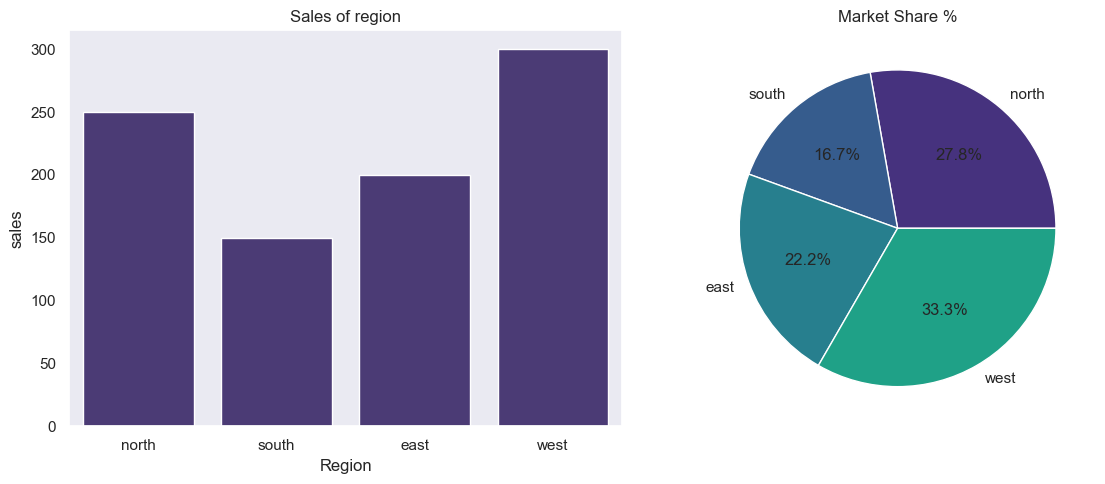

In [6]:
import pandas as pd

#simple sales dataset
data = {'Region':['north','south','east','west'],'sales':[250,150,200,300]}
df_sales = pd.DataFrame(data)

#creating a subplot area with 1 row and 2 column
fig, axes = plt.subplots(1,2, figsize=(12,5))

#plot 1: bar chart
sns.barplot(data=df_sales,x='Region',y='sales',ax=axes[0])
axes[0].set_title('Sales of region')

#plot 2: Pie chart
axes[1].pie(df_sales['sales'],labels = df_sales['Region'],autopct ='%1.1f%%')
axes[1].set_title('Market Share %')

plt.tight_layout()
plt.show()

Take away:
- if only 2 chart, the axes values remains 0 & 1.
- if 2d or more than 2 charts, the charts or the divided area is accessed by axes[1,1], axes[1,0] and so on
- we can set title for particular area by using axes[1].set_title()
- tight_layout() automatically formats the size of the chart based on the text size used in the chart like title, axes names etc..

### Interactive Chart by plotly

In [7]:
# %pip install plotly nbformat

In [8]:
import plotly.express as px

# Create an interactive scatter plot using the tips dataset
fig = px.scatter(tips, x='total_bill', y='tip', color='sex',hover_data=['day','size'], title='Interactive Scatter Plot of Total Bill vs Tip')
fig.show()

take away:
- the color attribute can be used as toggle button inside the chat, like in above chart if i clcik on male, the male data points hinds, only the female datapoints is shown in the chart
- the hover_data attribute is the hero here which allow user to hover over the datapoints to see more details abt the datapoint.

### Simple dashboard
using the help of subplots

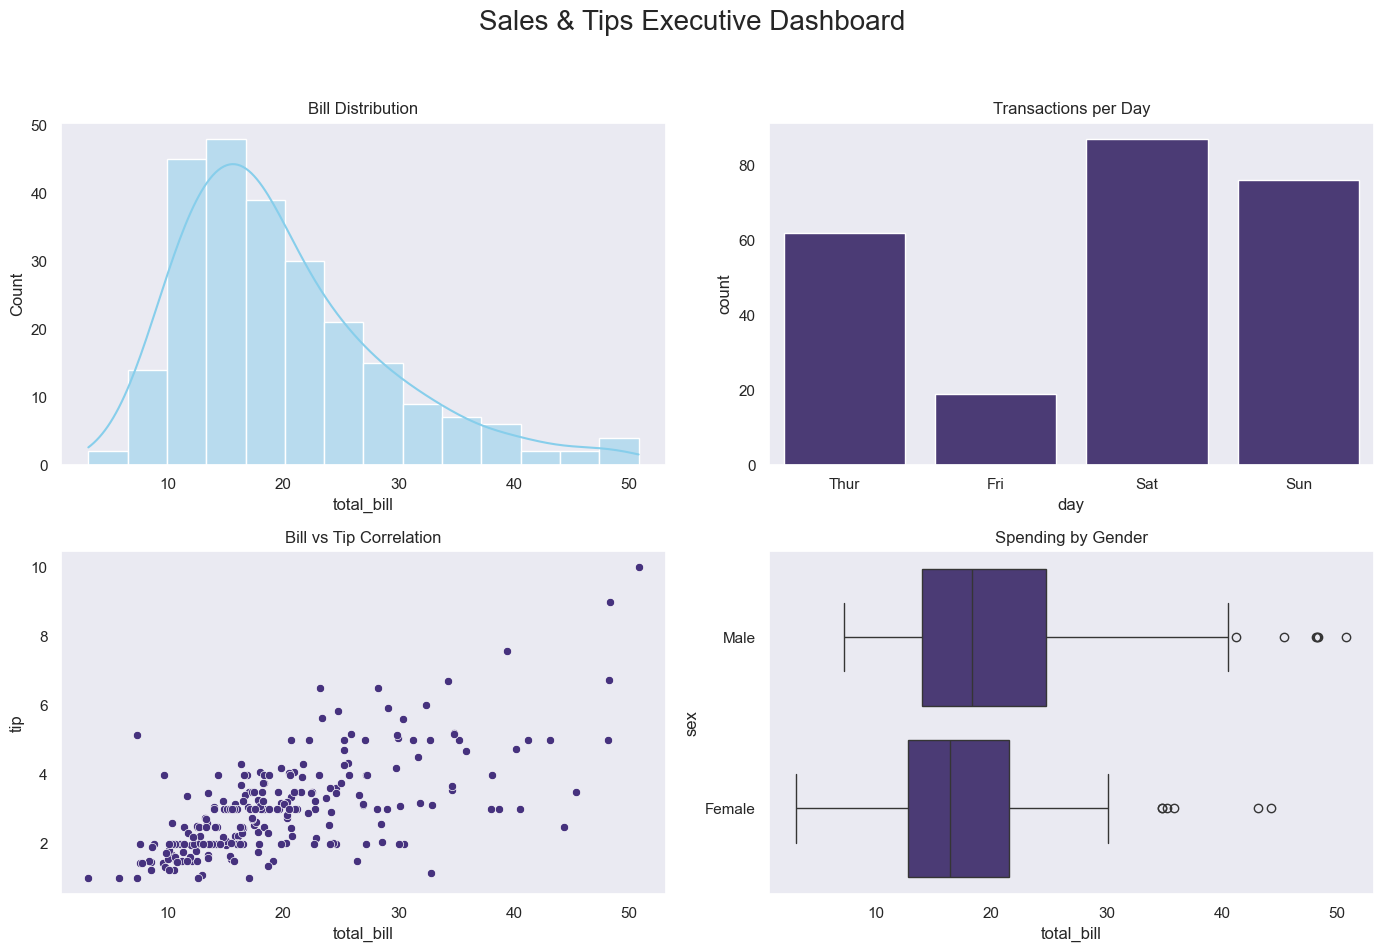

In [9]:
#this is AI copy pasted, but i can explain every sinlge line of code here.

# Setting up a 2x2 dashboard grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sales & Tips Executive Dashboard', fontsize=20)

# Top Left: Distribution
sns.histplot(tips['total_bill'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0,0].set_title('Bill Distribution')

# Top Right: Categories
sns.countplot(data=tips, x='day', ax=axes[0, 1])
axes[0,1].set_title('Transactions per Day')

# Bottom Left: Relations
sns.scatterplot(data=tips, x='total_bill', y='tip', ax=axes[1, 0])
axes[1,0].set_title('Bill vs Tip Correlation')

# Bottom Right: Comparison
sns.boxplot(data=tips, x='total_bill', y='sex', ax=axes[1, 1])
axes[1,1].set_title('Spending by Gender')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust to make room for suptitle
plt.show()

take away:
- using subplots and all the another things we can make a simple static dashboard
- instead of subplots we can use **GridSpec** for this
- but in the real world the dashboard should be made using Dash or streamlit. or even graido